In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
from torchvision.io import read_image
from torch.nn import functional as F 

from pathlib import Path
from torch.optim import AdamW
from torch.amp import GradScaler, autocast

from PIL import Image

import copy

import kagglehub
import os


from torchvision.transforms import functional as TF

import random

In [2]:
print("cuda" if torch.cuda.is_available() else "cpu")

cuda


In [3]:
def download():
    path = kagglehub.dataset_download('tawsifurrahman/covid19-radiography-database')
    print(f'data installed on {path}')
    return path

In [4]:
path = download()

data installed on C:\Users\panika\.cache\kagglehub\datasets\tawsifurrahman\covid19-radiography-database\versions\5


In [5]:
def analyze(path, sep='/'):
    path = path + sep + 'COVID-19_Radiography_Dataset'
    variants = ['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']

    i = 0
    total = 0
    for variant in variants:
        vpath = path + sep + variant + sep + 'images'
        count = len(os.listdir(vpath))
        total += count
        print(f'Вариантов картинок c типом {variant}: {count}')
        
        i += 1

    print(f'Общее количество картинок {total}')

In [6]:
analyze(path)

Вариантов картинок c типом COVID: 3369
Вариантов картинок c типом Lung_Opacity: 5573
Вариантов картинок c типом Normal: 10076
Вариантов картинок c типом Viral Pneumonia: 1343
Общее количество картинок 20361


In [7]:
def get_paired_paths(root_path, sep='/'):
    root_path = root_path + sep + 'COVID-19_Radiography_Dataset'
    variants = ['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']
    valid_pairs = []
    count = 0
    for var in variants:
        img_dir = Path(root_path) / var / 'images'
        mask_dir = Path(root_path) / var / 'masks'
            
        masks = sorted([f for f in os.listdir(mask_dir) if f.endswith('.png')])
        
        for mask_name in masks:
            img_path = img_dir / mask_name
            mask_path = mask_dir / mask_name
            
            if img_path.exists():
                valid_pairs.append((str(img_path), str(mask_path), var))
            else:
                # print(f"{mask_name}")
                count += 1
                
    print(f"Итого валидных пар для обучения: {len(valid_pairs)}")
    print(count)
    return valid_pairs

In [8]:
pairs = get_paired_paths(path)

Итого валидных пар для обучения: 20361
804


In [9]:
class XRayMaskDataset(Dataset):
    def __init__(self, pairs, transform=None):
        """
        pairs: список кортежей (path_to_image, path_to_mask, class_name)
        """
        self.pairs = pairs
        self.transform = transform
        self.class_map = {'COVID': 0, 'Lung_Opacity': 1, 'Normal': 2, 'Viral Pneumonia': 3}

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path, class_name = self.pairs[idx]
        
        image = Image.open(img_path).convert('L')
        mask = Image.open(mask_path).convert('L')
        
        if self.transform:
            seed = torch.seed()
            torch.manual_seed(seed)
            image = self.transform(image)
            
            torch.manual_seed(seed)
            mask = self.transform(mask)
            
        mask = (mask > 0).float()
        mask = mask * 2.0 - 1.0 
        
        class_id = torch.tensor(self.class_map[class_name], dtype=torch.long)
        
        return image, mask, class_id

In [10]:
def get_dataloader(pairs, batch_size=32, num_workers=4):
    transform = transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5])
    ])

    dataset = XRayMaskDataset(pairs, transform=transform)

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        pin_memory=True,
        drop_last=True
    )

    return loader

In [11]:
loader = get_dataloader(pairs)

In [12]:
class AttentionBlock(nn.Module):
    def __init__(self, channels, n_heads=1):
        super().__init__()
        self.channels = channels
        self.norm = nn.GroupNorm(32, channels)
        self.inner_dim = channels // 4

        self.q = nn.Conv2d(channels, self.inner_dim, kernel_size=1, bias=False)
        self.k = nn.Conv2d(channels, self.inner_dim, kernel_size=1, bias=False)
        self.v = nn.Conv2d(channels, channels, kernel_size=1, bias=False)

        self.proj_out = nn.Conv2d(channels, channels, kernel_size=1, bias=False)
        self.scale = self.inner_dim ** (-0.5)

    def forward(self, x):
        b, c, h, w = x.shape
        n = h * w
        h_ = self.norm(x)
        
        q = self.q(h_).view(b, self.inner_dim, n)
        k = self.k(h_).view(b, self.inner_dim, n)
        v = self.v(h_).view(b, c, n)

        attn = torch.einsum('b d i, b d j -> b i j', q, k)
        attn = torch.softmax(self.scale * attn, dim=-1)

        out = torch.einsum('b i j, b c j -> b c i', attn, v)

        out = out.view(b, c, h, w)
        return x + self.proj_out(out)

In [13]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, time_dim, groups=32):
        super().__init__()
        self.norm1 = nn.GroupNorm(groups, in_channels)
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)

        self.norm2 = nn.GroupNorm(groups, out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)

        self.time_mlp = nn.Linear(time_dim, out_channels)

        self.shortcut = nn.Conv2d(in_channels, out_channels, kernel_size=1) if in_channels != out_channels else nn.Identity()
        self.activation = F.silu

    def forward(self, x, time_embedding):
        h = self.norm1(x)
        h = self.activation(h)
        h = self.conv1(h)
                                  
        bias = self.time_mlp(self.activation(time_embedding))
        h = h + bias[:, :, None, None]

        h = self.norm2(h)
        h = self.activation(h)
        h = self.conv2(h)

        return h + self.shortcut(x)

In [14]:
class DownBlock(nn.Module):
    def __init__(self, in_channels, out_channels, time_dim):
        super().__init__()
        self.res = ResidualBlock(in_channels, out_channels, time_dim)
        self.down = nn.Conv2d(out_channels, out_channels, kernel_size=4, stride=2, padding=1)

    def forward(self, x, time_embedding):
        x = self.res(x, time_embedding)
        return x, self.down(x)

class UpBlock(nn.Module):
    def __init__(self, in_channels, out_channels, time_dim):
        super().__init__()
        self.res = ResidualBlock(in_channels, out_channels, time_dim)
        self.conv = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)

    def forward(self, x, skip, time_embedding):
        x = F.interpolate(x, scale_factor=2, mode="nearest")
        x = torch.cat([x, skip], dim=1)
        x = self.res(x, time_embedding)
        return self.conv(x)

In [15]:
class Unet128(nn.Module):
    def __init__(self, in_channels=2, out_channels=1, time_dim=256, num_classes=4):
        super().__init__()
        self.time_dim = time_dim
        
        self.class_emb = nn.Embedding(num_classes, time_dim)
        self.time_mlp = nn.Sequential(
            nn.Linear(time_dim, time_dim),
            nn.SiLU(),
            nn.Linear(time_dim, time_dim)
        )

        self.init_conv = nn.Conv2d(in_channels, 64, kernel_size=3, padding=1)

        self.down1 = DownBlock(64, 128, time_dim)
        self.down2 = DownBlock(128, 256, time_dim)
        self.attn2 = AttentionBlock(256)
        self.down3 = DownBlock(256, 512, time_dim)
        self.attn3 = AttentionBlock(512)
        self.down4 = DownBlock(512, 512, time_dim)

        self.res_mid1 = ResidualBlock(512, 512, time_dim)
        self.attn_mid = AttentionBlock(512)
        self.res_mid2 = ResidualBlock(512, 512, time_dim)

        self.up1 = UpBlock(1024, 512, time_dim)
        self.up2 = UpBlock(1024, 256, time_dim)
        self.up3 = UpBlock(512, 128, time_dim)
        self.up4 = UpBlock(256, 64, time_dim)

        self.final_conv = nn.Conv2d(64, out_channels, kernel_size=1)

    def pos_encoding(self, t, channels):
        inv_freq = 1.0 / (10000 ** (torch.arange(0, channels, 2).float().to(t.device) / channels))
        t = t.view(-1, 1)
        pos_enc_a = torch.sin(t * inv_freq)
        pos_enc_b = torch.cos(t * inv_freq)
        return torch.cat([pos_enc_a, pos_enc_b], dim=-1)

    def forward(self, x, mask, y, t):
        x = torch.cat([x, mask], dim=1)
        x = self.init_conv(x)

        t_emb = self.pos_encoding(t, self.time_dim)
        c_emb = self.class_emb(y)
        context = self.time_mlp(t_emb + c_emb)

        s1, x = self.down1(x, context)
        s2, x = self.down2(x, context)
        x = self.attn2(x)
        s3, x = self.down3(x, context)
        x = self.attn3(x)
        s4, x = self.down4(x, context)

        x = self.res_mid1(x, context)
        x = self.attn_mid(x)
        x = self.res_mid2(x, context)

        x = self.up1(x, s4, context)
        x = self.up2(x, s3, context)
        x = self.up3(x, s2, context)
        x = self.up4(x, s1, context)

        return self.final_conv(x)

In [16]:
def get_cosine_schedule(timesteps, s=0.008):
    steps = timesteps + 1
    t = torch.linspace(0, timesteps, steps)
    alphas_cumprod = torch.cos(((t / timesteps) + s) / (1 + s) * torch.pi * 0.5) ** 2
    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
    betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
    
    return torch.clamp(betas, 0.0001, 0.9999)

In [17]:
@torch.no_grad()
def sample_from_mask(model, mask_path, label_id, alphas, alphas_cumprod, betas, device):
    T = len(alphas)
    mask_pil = Image.open(mask_path).convert('L')
    mask_pil = TF.resize(mask_pil, (128, 128), interpolation=TF.InterpolationMode.NEAREST)
    mask = TF.to_tensor(mask_pil).to(device).unsqueeze(0) 
    mask = (mask > 0.5).float()
    mask = mask * 2.0 - 1.0 
    
    y = torch.tensor([label_id], device=device).long()
    x = torch.randn((1, 1, 128, 128), device=device)
    
    for i in reversed(range(0, 1000)):
        t = torch.tensor([i], device=device).long()

        with torch.amp.autocast('cuda'):
            epsilon_pred = model(x, mask, y, t)
        
        a = alphas[i]
        a_cp = alphas_cumprod[i]
        b = betas[i]
        
        z = torch.randn_like(x) if i > 0 else 0
            
        coeff = (1 - a) / torch.sqrt(1 - a_cp + 1e-7)
        mu = (1 / torch.sqrt(a)) * (x - coeff * epsilon_pred)
        sigma = torch.sqrt(b)
        
        x = mu + sigma * z
        
        x = x.clamp(-1,1)
        
    return x

In [18]:
def report(meta):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    def install(version, name):
        model = Unet128()
        checkpoint = torch.load(f'../models/{version}/{name}', weights_only=False)
        model.load_state_dict(checkpoint['model_state_dict'])
        epoch = checkpoint['epoch']
        avg_loss = checkpoint['loss']
        print(f"Load model ({version}/{name}) from epoch {epoch} with loss {avg_loss}")
        return model

    def generate(meta, model):
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        T = 1000
        betas = get_cosine_schedule(T).to(device)
        alphas = 1.0 - betas
        alphas_cumprod = torch.cumprod(alphas, dim=0)
        type_to_class = {0: 'COVID', 1: 'Lung_Opacity', 2: 'Normal', 3: 'Viral Pneumonia'}
        path = meta['path'] + '\\COVID-19_Radiography_Dataset\\'
        images = []
        for i in range(len(meta['masks'])):
            tt = type_to_class[meta['masks_types'][i]]
            image = sample_from_mask(
                model=model,
                mask_path=path + f'{tt}\\masks\\{tt}-{meta['masks'][i]}.png',
                label_id=meta['disease'][i],
                alphas=alphas,
                alphas_cumprod=alphas_cumprod,
                betas=betas,
                device=device
            ).view(128, 128).to('cpu')
            images.append([image, type_to_class[meta['disease'][i]], tt, meta['masks'][i], 'Generate'])
        return images

    def add_real(meta, images):
        type_to_class = {0: 'COVID', 1: 'Lung_Opacity', 2: 'Normal', 3: 'Viral Pneumonia'}
        path = meta['path'] + '\\COVID-19_Radiography_Dataset\\'
        for i in range(len(meta['real'])):
            tt = type_to_class[meta['real_types'][i]]
            img_path = path + f'{tt}\\images\\{tt}-{meta['real'][i]}.png'
            img = Image.open(img_path).convert('L')
            img_resized = img.resize((128, 128), Image.Resampling.LANCZOS)
            transform = transforms.ToTensor()
            image = transform(img_resized).squeeze(0)
            images.append([image, tt, tt, tt, 'Real'])
        return images

    def fill(meta, axes, images):
        for i in range(len(images)):
            ax = axes.flat[i]
            ax.imshow(images[i][0], cmap=meta['cmap'], aspect='auto')
            if meta['title']:
                ax.set_title(f'{images[i][4]} {images[i][1]}({images[i][2]}-{images[i][3]})', fontsize=4)
            ax.axis('off')

    if meta['jsf']:
        fig1, axes1 = plt.subplots(meta['y'], meta['x'])
        fill(meta, axes1, meta['js'][0])
        plt.show(fig1)

        return meta['js']
        
    result = []
    
    if meta['use_casual']:
        model = install(meta['version'], meta['name'])
        model.to(device)
        model.eval()
        images = generate(meta, model)
        images = add_real(meta, images)
        if meta['shuffle']:
            random.shuffle(images)
        result.append(images)
    
        fig1, axes1 = plt.subplots(meta['y'], meta['x'], figsize=(10, 5), constrained_layout=True)
        fig1.suptitle('Генерация обычной модели', fontsize=16)
        fill(meta, axes1, images)
        plt.show(fig1)
        
    if meta['use_ema']:
        ema_model = install(meta['version'], meta['name_ema'])
        ema_model.to(device)
        ema_model.eval()
        images = generate(meta, ema_model)
        images = add_real(meta, images)
        if meta['shuffle']:
            random.shuffle(images)
        result.append(images)
        fig2, axes2 = plt.subplots(meta['y'], meta['x'])
        fig2.suptitle('Генерация ema модели', fontsize=16)
        fill(meta, axes2, images)
        plt.show(fig2)

    return result

Load model (v101/unet128_checkpoint.pth) from epoch 192 with loss 0.002635585994762808


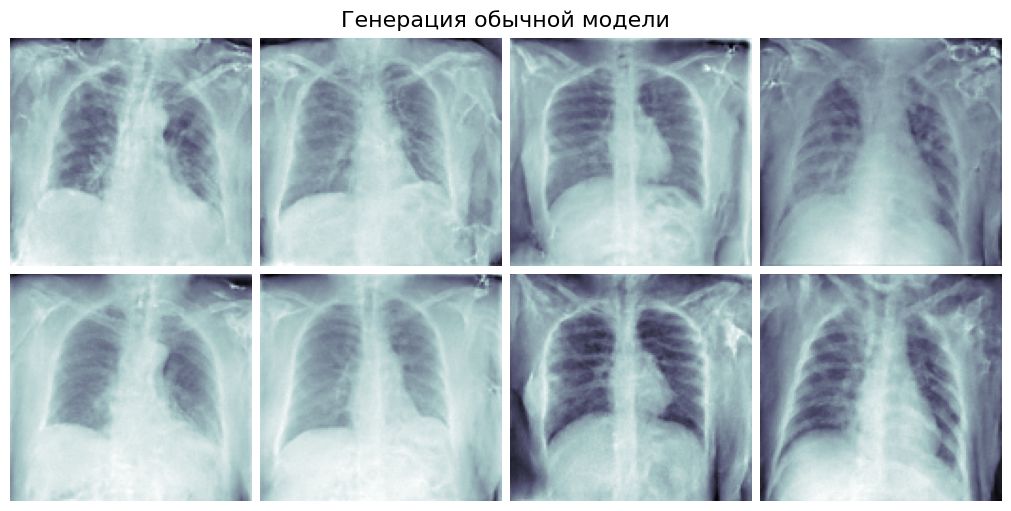

Load model (v101/unet128_checkpoint_ema.pth) from epoch 192 with loss 0.002635585994762808


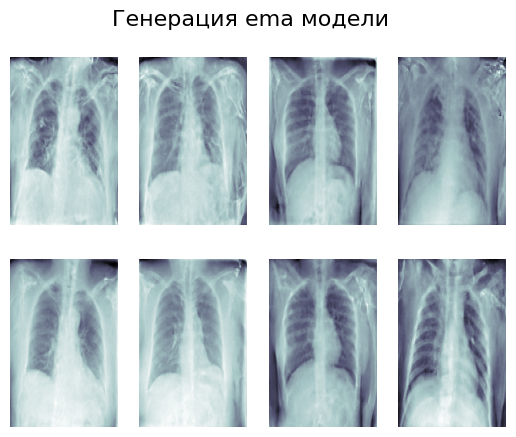

CPU times: total: 4min 18s
Wall time: 4min 31s


In [23]:
%%time
# COVID - 0, Lung_Opacity - 1, Normal - 2, Viral Peumonia - 3
disease = [0, 0, 1, 1, 2, 2, 3, 3]
masks_types = [0, 1, 2, 3, 0, 1, 2, 3]
masks = [1, 1, 1, 1, 1, 1, 1, 1]
real_types = []
real = []

meta = {
    'path' : path,
    'name' : 'unet128_checkpoint.pth',
    'name_ema' : 'unet128_checkpoint_ema.pth',
    'version' : 'v101',
    'use_casual' : True,
    'use_ema' : True,
    'masks_types': masks_types, 
    'masks' : masks,
    'real_types' : real_types,
    'real' : real,
    'disease': disease,
    'shuffle' : False,
    'x': 4,
    'y': 2,
    'cmap' : 'bone',
    'title' : False,
    'save' : None,
    'save_ema' : None,
    'jsf': False,
    'js' : None
}

result = report(meta)